# WarpAUV Tracking Evaluation

This notebook can run `play_eval_for_publication_pos.py`, load the generated `logs.csv`, and plot paper-style tracking curves.

In [36]:
# Edit these values before running the notebook.
repo_root = "/home/jining_yang/IsaacLab"
task_name = "Isaac-WarpAUV-Direct-v1"

# Option A: set csv_path directly.
csv_path = ""  # e.g. "/tmp/warpauv_nominal_logs.csv"

# Option B: leave csv_path empty and set run/checkpoint info.
load_run = "2026-06-12_14-33-57"
checkpoint = "model_799.pt"
experiment_name = "warpauv_traj_direct"

# Training settings. Set run_train = True to launch training from this notebook.
run_train = False
train_num_envs = 2048
train_headless = True
train_extra_args = []  # e.g. ["--logger", "tensorboard"]

# Evaluation settings. Set run_eval = True to launch Isaac Sim from this notebook.
run_eval = True
eval_name = "eval_nominal_model399"
com_cob_offset = 0.0
volume = 0.022747843530591776
action_noise_std = 0.0
observation_noise_std = 0.0

# Plot settings.
out_path = ""  # leave empty to save beside logs.csv
dt = 1.0 / 60.0
steps_per_goal = 300
title = "WarpAUV Tracking Evaluation"

## Train A New Policy

`load_run` is the timestamp folder name under `logs/rsl_rl/warpauv_direct/`, for example `2026-06-08_14-40-56`. After training, run the "List recent runs" cell and copy the newest folder name into `load_run` in the first cell.

In [8]:
import os
import shlex

train_script = "scripts/reinforcement_learning/rsl_rl/train.py"
train_command = [
    "./isaaclab.sh",
    "-p",
    train_script,
    "--task",
    task_name,
    "--num_envs",
    str(train_num_envs),
]
if train_headless:
    train_command.append("--headless")
train_command.extend(train_extra_args)

print("Training command:")
print(" ".join(shlex.quote(part) for part in train_command))

Training command:
./isaaclab.sh -p scripts/reinforcement_learning/rsl_rl/train.py --task Isaac-WarpAUV-Direct-v1 --num_envs 2048 --headless


In [9]:
import subprocess

if run_train:
    env = os.environ.copy()
    env.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
    subprocess.run(train_command, cwd=repo_root, env=env, check=True)
else:
    print("run_train is False, so training was not launched. Set run_train = True in the first cell to run it here.")

[INFO] Using python from: /home/jining_yang/miniconda3/envs/env_isaaclab/bin/python H    H    H    H    H    H   
[INFO][AppLauncher]: Using device: cuda:0
[INFO][AppLauncher]: Loading experience file: /home/jining_yang/IsaacLab/apps/isaaclab.python.headless.kit
Loading user config located at: '/home/jining_yang/miniconda3/envs/env_isaaclab/lib/python3.11/site-packages/isaacsim/kit/data/Kit/Isaac-Sim/5.1/user.config.json'
[Info] [carb] Logging to file: /home/jining_yang/miniconda3/envs/env_isaaclab/lib/python3.11/site-packages/isaacsim/kit/logs/Kit/Isaac-Sim/5.1/kit_20260608_151013.log
2026-06-08T07:10:13Z s] [Warning] [omni.ext.plugin] [ext: results] Extensions config 'extension.toml' doesn't exist '/home/jining_yang/IsaacLab/source/results' or '/home/jining_yang/IsaacLab/source/results/config'
2026-06-08T07:10:13Z s] [Warning] [omni.usd_config.extension] Enable omni.materialx.libs extension to use MaterialX
2026-06-08T07:10:14Z s] [Warning] [carb] Acquiring non optional plugin 

cat: '/sys/devices/system/cpu/cpu*/cpufreq/scaling_governor': No such file or directory


[INFO]: Parsing configuration from: <class 'isaaclab_tasks.direct.isaac-auv-env.warpauv_env.WarpAUVEnvCfg'>
[INFO]: Parsing configuration from: <class 'isaaclab_tasks.direct.isaac-auv-env.agents.rsl_rl_ppo_cfg.WarpAUVPPORunnerCfg'>


/home/jining_yang/miniconda3/envs/env_isaaclab/lib/python3.11/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/jining_yang/miniconda3/envs/env_isaaclab/lib/python3.11/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


[INFO] Logging experiment in directory: /home/jining_yang/IsaacLab/logs/rsl_rl/warpauv_direct
Exact experiment name requested from command line: 2026-06-08_15-10-19
[2026-06-08 15:10:19,810][__main__][WARNING] - IO descriptors are only supported for manager based RL environments. No IO descriptors will be exported.

[INFO][IsaacLab]: Logging to file: /tmp/isaaclab/logs/isaaclab_2026-06-08_15-10-19.log

15:10:19 [simulation_context.py] WARNING: The `enable_external_forces_every_iteration` parameter in the PhysxCfg is set to False. If you are experiencing noisy velocities, consider enabling this flag. You may need to slightly increase the number of velocity iterations (setting it to 1 or 2 rather than 0), together with this flag, to improve the accuracy of velocity updates.
[INFO]: Base environment:
	Environment device    : cuda:0
	Environment seed      : 42
	Physics step-size     : 0.008333333333333333
	Rendering step-size   : 0.008333333333333333
	Environment step-size : 0.016666666666

/home/jining_yang/miniconda3/envs/env_isaaclab/lib/python3.11/site-packages/rsl_rl/utils/utils.py:245: UserWarning: The observation configuration dictionary 'obs_groups' must contain the 'policy' key. As an observation group with the name 'policy' was found, this is assumed to be the observation set. Consider adding the 'policy' key to the 'obs_groups' dictionary for clarity. This behavior will be removed in a future version.
  warnings.warn(
/home/jining_yang/miniconda3/envs/env_isaaclab/lib/python3.11/site-packages/rsl_rl/utils/utils.py:291: UserWarning: The observation configuration dictionary 'obs_groups' must contain the 'critic' key. As the configuration for 'critic' is missing, the observations from the 'policy' set are used. Consider adding the 'critic' key to the 'obs_groups' dictionary for clarity. This behavior will be removed in a future version.
  warnings.warn(


################################################################################
                        Learning iteration 0/400                        

                       Computation: 46714 steps/s (collection: 0.894s, learning 0.158s)
             Mean action noise std: 0.99
          Mean value_function loss: 2.6831
               Mean surrogate loss: -0.0038
                 Mean entropy loss: 8.4844
                       Mean reward: 3.42
               Mean episode length: 19.93
--------------------------------------------------------------------------------
                   Total timesteps: 49152
                    Iteration time: 1.05s
                      Time elapsed: 00:00:01
                               ETA: 00:07:00

Could not find git repository in /home/jining_yang/miniconda3/envs/env_isaaclab/lib/python3.11/site-packages/rsl_rl/__init__.py. Skipping.
Storing git diff for 'IsaacLab' in: /home/jining_yang/IsaacLab/logs/rsl_rl/warpauv_direct/2026-06-08_15-10-1

In [34]:
from pathlib import Path

runs_root = Path(repo_root) / "logs" / "rsl_rl" / experiment_name
runs = sorted([p for p in runs_root.glob("*") if p.is_dir()], key=lambda p: p.stat().st_mtime, reverse=True)
print(f"Runs root: {runs_root}")
for p in runs[:10]:
    ckpts = sorted(p.glob("model_*.pt"))
    latest_ckpt = ckpts[-1].name if ckpts else "no checkpoint"
    print(f"load_run = {p.name}    latest checkpoint = {latest_ckpt}")

Runs root: /home/jining_yang/IsaacLab/logs/rsl_rl/warpauv_direct
load_run = 2026-06-12_14-17-13    latest checkpoint = model_50.pt
load_run = 2026-06-11_18-26-15    latest checkpoint = model_799.pt
load_run = 2026-06-11_17-26-31    latest checkpoint = model_50.pt
load_run = 2026-06-11_17-20-07    latest checkpoint = model_0.pt
load_run = 2026-06-11_17-07-16    latest checkpoint = model_50.pt
load_run = 2026-06-11_17-05-19    latest checkpoint = model_0.pt
load_run = 2026-06-11_16-28-20    latest checkpoint = model_50.pt
load_run = 2026-06-08_15-10-19    latest checkpoint = model_50.pt
load_run = 2026-06-08_14-40-56    latest checkpoint = model_50.pt
load_run = 2026-06-08_10-45-19    latest checkpoint = model_50.pt


## Run Position/Attitude Evaluation

If `logs.csv` does not exist yet, set `load_run` above and set `run_eval = True`, then run the next two cells. The command is the notebook version of replacing `<RUN>` in the terminal command.

In [37]:
import os
import shlex

eval_script = "source/isaaclab_tasks/isaaclab_tasks/direct/isaac-auv-env/custom_workflows/play_eval_for_publication_pos.py"
eval_command = [
    "./isaaclab.sh",
    "-p",
    eval_script,
    "--task",
    task_name,
    "--load_run",
    load_run,
    "--checkpoint",
    checkpoint,
    "--eval_name",
    eval_name,
    "--com_cob_offset",
    str(com_cob_offset),
    "--volume",
    str(volume),
    "--action_noise_std",
    str(action_noise_std),
    "--observation_noise_std",
    str(observation_noise_std),
]

if not load_run and not csv_path:
    print("Set load_run to your training run folder before running eval, or set csv_path to an existing logs.csv.")
else:
    print(" ".join(shlex.quote(part) for part in eval_command))

./isaaclab.sh -p source/isaaclab_tasks/isaaclab_tasks/direct/isaac-auv-env/custom_workflows/play_eval_for_publication_pos.py --task Isaac-WarpAUV-Direct-v1 --load_run 2026-06-12_14-33-57 --checkpoint model_799.pt --eval_name eval_nominal_model399 --com_cob_offset 0.0 --volume 0.022747843530591776 --action_noise_std 0.0 --observation_noise_std 0.0


In [38]:
import subprocess

if run_eval:
    if not load_run:
        raise ValueError("Set load_run before running eval from the notebook.")
    env = os.environ.copy()
    env.setdefault("WANDB_MODE", "offline")
    env.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
    subprocess.run(eval_command, cwd=repo_root, env=env, check=True)
else:
    print("run_eval is False, so eval was not launched. Set run_eval = True in the first cell to run it here.")

[INFO] Using python from: /home/jining_yang/miniconda3/envs/env_isaaclab/bin/python H    H    H    H    H    H   
[INFO][AppLauncher]: Using device: cuda:0
[INFO][AppLauncher]: Loading experience file: /home/jining_yang/IsaacLab/apps/isaaclab.python.kit
Loading user config located at: '/home/jining_yang/miniconda3/envs/env_isaaclab/lib/python3.11/site-packages/isaacsim/kit/data/Kit/Isaac-Sim/5.1/user.config.json'
[Info] [carb] Logging to file: /home/jining_yang/miniconda3/envs/env_isaaclab/lib/python3.11/site-packages/isaacsim/kit/logs/Kit/Isaac-Sim/5.1/kit_20260612_145408.log
2026-06-12T06:54:08Z s] [Warning] [omni.ext.plugin] [ext: results] Extensions config 'extension.toml' doesn't exist '/home/jining_yang/IsaacLab/source/results' or '/home/jining_yang/IsaacLab/source/results/config'
[0.066s] [ext: omni.kit.async_engine-0.0.3] startup
[0.227s] [ext: omni.metrics.core-0.0.3] startup
[0.228s] [ext: omni.client.lib-1.1.0] startup
[0.242s] [ext: omni.blobkey-1.1.2] startup
[0.242s

cat: '/sys/devices/system/cpu/cpu*/cpufreq/scaling_governor': No such file or directory


[1.834s] [ext: omni.kit.pipapi-0.0.0] startup
[1.834s] [ext: omni.usd.config-1.0.6] startup
[1.838s] [ext: omni.gpucompute.plugins-0.0.0] startup
[1.839s] [ext: omni.usd.libs-1.0.1] startup
[1.934s] [ext: omni.kit.pip_archive-0.0.0] startup
[1.934s] [ext: omni.mdl-56.0.3] startup
[2.052s] [ext: omni.iray.libs-0.0.0] startup
[2.061s] [ext: omni.mdl.neuraylib-0.2.12] startup
[2.064s] [ext: omni.kit.usd.mdl-1.1.5] startup
[2.162s] [ext: omni.kit.telemetry-0.5.2] startup
[2.185s] [ext: omni.appwindow-1.1.10] startup
[2.192s] [ext: omni.kit.renderer.core-1.1.0] startup
[2.313s] [ext: omni.kit.renderer.capture-0.0.0] startup
[2.317s] [ext: omni.kit.renderer.imgui-2.0.5] startup
[2.394s] [ext: omni.ui-2.27.1] startup
[2.404s] [ext: omni.kit.mainwindow-1.0.3] startup
[2.405s] [ext: carb.audio-0.1.0] startup
[2.432s] [ext: omni.uiaudio-1.0.0] startup
[2.434s] [ext: omni.kit.uiapp-0.0.0] startup
[2.434s] [ext: omni.usd.schema.metrics.assembler-107.3.1] startup
[2.436s] [ext: omni.usd.schema.omni

Traceback (most recent call last):
  File "/home/jining_yang/IsaacLab/source/isaaclab_tasks/isaaclab_tasks/utils/parse_cfg.py", line 205, in get_checkpoint_path
    run_path = runs[-1]
               ~~~~^^^^
IndexError: list index out of range

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/jining_yang/IsaacLab/source/isaaclab_tasks/isaaclab_tasks/direct/isaac-auv-env/custom_workflows/play_eval_for_publication_pos.py", line 263, in <module>
    main()
  File "/home/jining_yang/IsaacLab/source/isaaclab_tasks/isaaclab_tasks/direct/isaac-auv-env/custom_workflows/play_eval_for_publication_pos.py", line 94, in main
    resume_path = get_checkpoint_path(log_root_path, agent_cfg.load_run, agent_cfg.load_checkpoint)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/jining_yang/IsaacLab/source/isaaclab_tasks/isaaclab_tasks/utils/parse_cfg.py", line 207, in get_

2026-06-12T06:54:27Z [18,934ms] [Warning] [omni.graph.core.plugin] Could not find category 'Replicator:Annotators' for removal
2026-06-12T06:54:27Z [18,934ms] [Warning] [omni.graph.core.plugin] Could not find category 'Replicator:Annotators' for removal
2026-06-12T06:54:27Z [18,934ms] [Warning] [omni.graph.core.plugin] Could not find category 'Replicator' for removal
2026-06-12T06:54:27Z [18,934ms] [Warning] [omni.graph.core.plugin] Could not find category 'Replicator:Annotators' for removal
2026-06-12T06:54:27Z [18,934ms] [Warning] [omni.graph.core.plugin] Could not find category 'Replicator:Annotators' for removal
2026-06-12T06:54:27Z [18,934ms] [Warning] [omni.graph.core.plugin] Could not find category 'Replicator:Annotators' for removal
2026-06-12T06:54:27Z [18,934ms] [Warning] [omni.graph.core.plugin] Could not find category 'Replicator:Annotators' for removal
2026-06-12T06:54:27Z [18,934ms] [Warning] [omni.graph.core.plugin] Could not find category 'Replicator:Annotators' for rem

In [26]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def resolve_paths(csv_path, load_run, checkpoint, experiment_name, out_path):
    if csv_path:
        resolved_csv = csv_path if os.path.isabs(csv_path) else os.path.join(repo_root, csv_path)
        resolved_out = out_path or os.path.splitext(csv_path)[0] + "_tracking.png"
        if not os.path.isabs(resolved_out):
            resolved_out = os.path.join(repo_root, resolved_out)
        return resolved_csv, resolved_out

    if not load_run:
        raise ValueError("Set either csv_path or load_run in the first cell.")

    result_dir = os.path.join(
        repo_root,
        "source",
        "results",
        "rsl_rl",
        experiment_name,
        load_run,
        checkpoint[:-3] + "_play",
    )
    resolved_csv = os.path.join(result_dir, "logs.csv")
    resolved_out = out_path or os.path.join(result_dir, "tracking_eval.png")
    return resolved_csv, resolved_out


def require_columns(df, columns, csv_path):
    missing = [col for col in columns if col not in df.columns]
    if missing:
        raise ValueError(
            f"Missing columns in {csv_path}: {missing}\n"
            "This notebook expects logs from play_eval_for_publication_pos.py. "
            "Rerun that eval script after the pandas logging fix."
        )


def draw_goal_boundaries(axes, steps_per_goal):
    if steps_per_goal <= 0:
        return
    for ax in axes:
        xmax = ax.get_xlim()[1]
        for step in range(steps_per_goal, int(xmax) + 1, steps_per_goal):
            ax.axvline(step * dt, color="0.8", linewidth=0.8, linestyle=":")

In [27]:
resolved_csv, resolved_out = resolve_paths(csv_path, load_run, checkpoint, experiment_name, out_path)
df = pd.read_csv(resolved_csv)

required = [
    "goal_x",
    "goal_y",
    "goal_z",
    "true_x",
    "true_y",
    "true_z",
    "goal_roll",
    "goal_pitch",
    "goal_yaw",
    "true_roll",
    "true_pitch",
    "true_yaw",
    "pos_error",
    "ang_error",
    "action_cost",
    "total_reward",
]
require_columns(df, required, resolved_csv)

print(f"Loaded: {resolved_csv}")
print(f"Rows: {len(df)}")
df.head()

Loaded: /home/jining_yang/IsaacLab/source/results/rsl_rl/warpauv_direct/2026-06-11_18-26-15/model_799_play/logs.csv
Rows: 3600


,goal_roll,goal_pitch,goal_yaw,goal_x,goal_y,goal_z,true_roll,true_pitch,true_yaw,true_x,...,pos_error,ang_error,linvel_error,angvel_error,pos_reward,ang_reward,linvel_reward,angvel_reward,action_reward,total_reward
0,0.0,0.0,0.0,1,0,0,5.176564e-16,-2.579769e-17,4.681374e-17,4.470348e-08,...,1.000000,2.101605e-17,0.000086,4.521574e-17,0.073576,0.500000,0.050000,0.050000,-0.037737,0.635839
1,0.0,0.0,0.0,1,0,0,-7.220288e-07,5.961120e-05,-6.068174e-06,1.554191e-05,...,0.999984,5.993771e-05,0.000701,5.664236e-03,0.073578,0.499970,0.050000,0.049998,-0.037736,0.635811
2,0.0,0.0,0.0,1,0,0,-4.004637e-06,4.053421e-04,-4.149825e-05,9.956956e-05,...,0.999900,4.074771e-04,0.003446,2.619954e-02,0.073591,0.499796,0.049999,0.049966,-0.037493,0.635859
3,0.0,0.0,0.0,1,0,0,-2.191800e-05,1.341369e-03,-1.344551e-04,3.301203e-04,...,0.999670,1.348299e-03,0.009220,6.715807e-02,0.073624,0.499326,0.049996,0.049775,-0.036636,0.636086
4,0.0,0.0,0.0,1,0,0,-9.833207e-05,3.219434e-03,-3.077761e-04,8.033812e-04,...,0.999197,3.235526e-03,0.018769,1.292810e-01,0.073694,0.498385,0.049982,0.049171,-0.035046,0.636187


Saved plot: /home/jining_yang/IsaacLab/source/results/rsl_rl/warpauv_direct/2026-06-11_18-26-15/model_799_play/tracking_eval.png


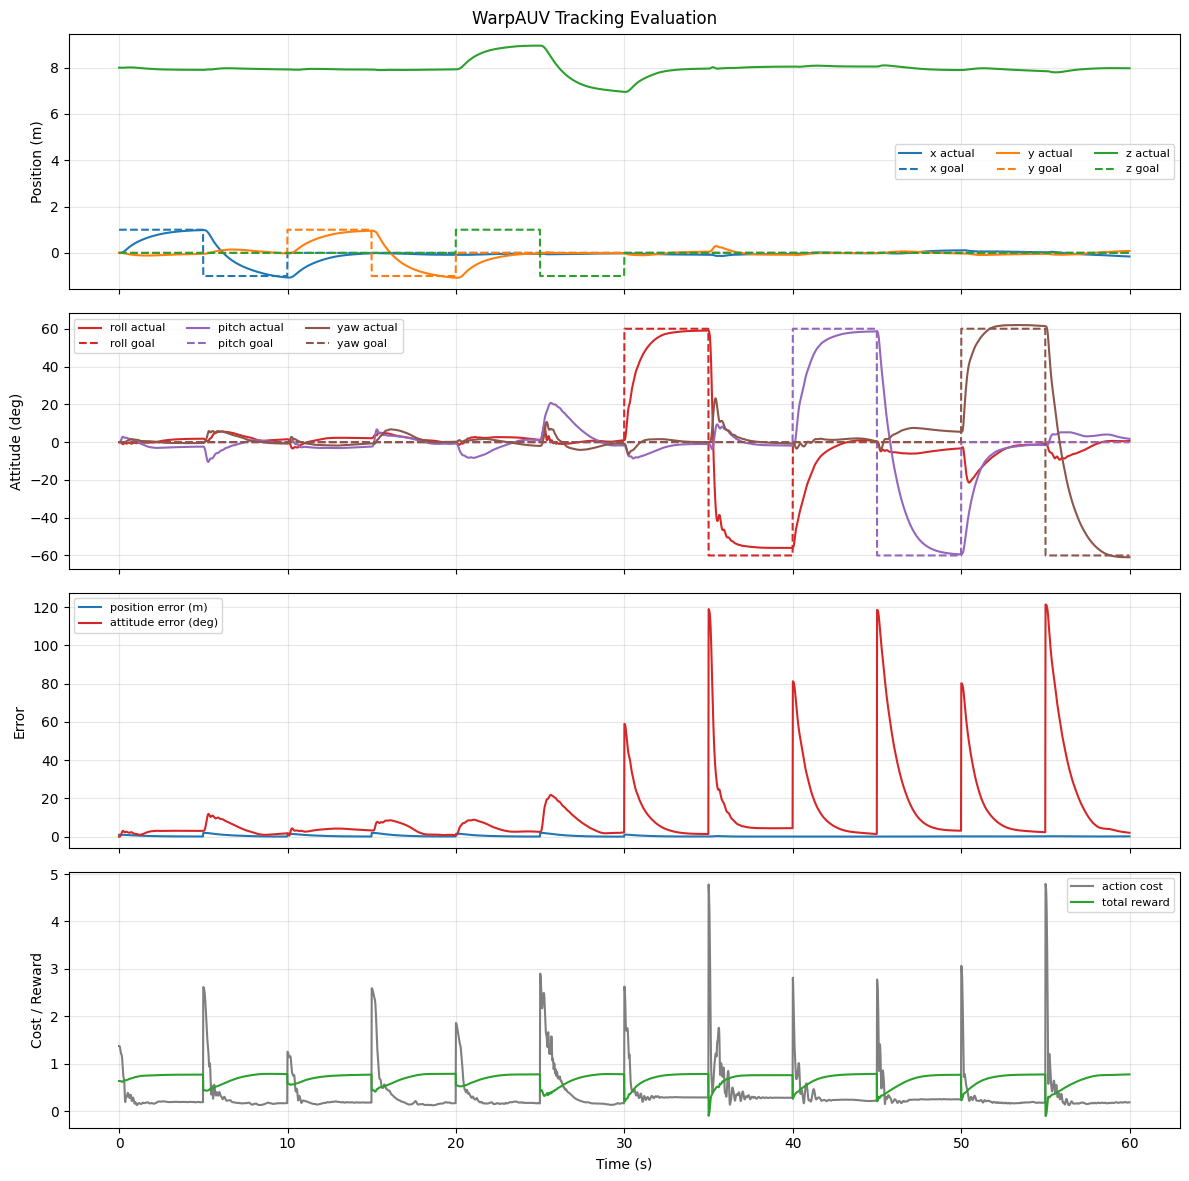

In [28]:
t = np.arange(len(df)) * dt
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)
fig.suptitle(title)

colors = {"x": "tab:blue", "y": "tab:orange", "z": "tab:green"}
for axis_name in ("x", "y", "z"):
    axes[0].plot(t, df[f"true_{axis_name}"], color=colors[axis_name], label=f"{axis_name} actual")
    axes[0].plot(t, df[f"goal_{axis_name}"], color=colors[axis_name], linestyle="--", label=f"{axis_name} goal")
axes[0].set_ylabel("Position (m)")
axes[0].grid(True, alpha=0.3)
axes[0].legend(ncol=3, fontsize=8)

angle_colors = {"roll": "tab:red", "pitch": "tab:purple", "yaw": "tab:brown"}
for angle in ("roll", "pitch", "yaw"):
    axes[1].plot(t, np.rad2deg(df[f"true_{angle}"]), color=angle_colors[angle], label=f"{angle} actual")
    axes[1].plot(t, np.rad2deg(df[f"goal_{angle}"]), color=angle_colors[angle], linestyle="--", label=f"{angle} goal")
axes[1].set_ylabel("Attitude (deg)")
axes[1].grid(True, alpha=0.3)
axes[1].legend(ncol=3, fontsize=8)

axes[2].plot(t, df["pos_error"], label="position error (m)", color="tab:blue")
axes[2].plot(t, np.rad2deg(df["ang_error"]), label="attitude error (deg)", color="tab:red")
axes[2].set_ylabel("Error")
axes[2].grid(True, alpha=0.3)
axes[2].legend(fontsize=8)

axes[3].plot(t, df["action_cost"], label="action cost", color="tab:gray")
axes[3].plot(t, df["total_reward"], label="total reward", color="tab:green")
axes[3].set_ylabel("Cost / Reward")
axes[3].set_xlabel("Time (s)")
axes[3].grid(True, alpha=0.3)
axes[3].legend(fontsize=8)

draw_goal_boundaries(axes, steps_per_goal)
fig.tight_layout()

os.makedirs(os.path.dirname(resolved_out) or ".", exist_ok=True)
fig.savefig(resolved_out, dpi=180)
print(f"Saved plot: {resolved_out}")
plt.show()

In [43]:
summary = pd.DataFrame(
    {
        "metric": ["pos_error", "ang_error_rad", "ang_error_deg", "action_cost", "total_reward"],
        "mean": [
            df["pos_error"].mean(),
            df["ang_error"].mean(),
            np.rad2deg(df["ang_error"]).mean(),
            df["action_cost"].mean(),
            df["total_reward"].mean(),
        ],
        "final": [
            df["pos_error"].iloc[-1],
            df["ang_error"].iloc[-1],
            np.rad2deg(df["ang_error"]).iloc[-1],
            df["action_cost"].iloc[-1],
            df["total_reward"].iloc[-1],
        ],
        "max": [
            df["pos_error"].max(),
            df["ang_error"].max(),
            np.rad2deg(df["ang_error"]).max(),
            df["action_cost"].max(),
            df["total_reward"].max(),
        ],
    }
)
summary

,metric,mean,final,max
0,pos_error,0.162059,0.000000,1.000000
1,ang_error_rad,0.193532,1.047200,1.047200
2,ang_error_deg,11.088588,60.000145,60.000152
3,action_cost,0.236866,0.151190,1.857649
4,total_reward,0.662708,0.366998,0.698187
